# Feature Selection for Potato Disease Classification

This notebook demonstrates the feature selection process for the potato disease classification project. We'll explore:

1. **Feature Extraction**: Extract various types of features from potato leaf images
2. **Feature Analysis**: Analyze the importance and correlation of features
3. **Feature Selection Methods**: Compare different techniques for selecting optimal features
4. **Model Performance**: Evaluate how feature selection affects model accuracy

## Dataset Overview
Our dataset contains images of potato leaves with three classes:
- **Healthy**: Normal potato leaves
- **Early Blight**: Caused by *Alternaria solani* fungus
- **Late Blight**: Caused by *Phytophthora infestans* water mold

In [ ]:
# Import required libraries
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif, RFE, mutual_info_classif
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Add project root to path for imports
project_root = os.path.abspath('..')
sys.path.append(project_root)
sys.path.append(os.path.join(project_root, 'src'))
sys.path.append(os.path.join(project_root, 'scripts'))

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")
print(f"Project root: {project_root}")

In [ ]:
# Load the features dataset
features_file = os.path.join(project_root, 'data', 'features', 'extracted_features.csv')

if not os.path.exists(features_file):
    print(f"Features file not found at {features_file}")
    print("Please run feature extraction first using:")
    print("python scripts/extract_potato_features.py --input data/processed --output data/features/extracted_features.csv")
else:
    # Load the dataset
    df = pd.read_csv(features_file)
    print(f"Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
    print(f"Classes: {df['class'].value_counts()}")
    
    # Display basic info
    print("\nDataset Info:")
    print(df.info())
    
    # Display first few rows
    print("\nFirst 5 rows:")
    print(df.head())

In [ ]:
# Analyze features if dataset exists
if 'df' in locals():
    # Remove non-feature columns
    feature_cols = [col for col in df.columns if col not in ['class', 'image_path']]
    X = df[feature_cols]
    y = df['class']
    
    print(f"Number of features: {len(feature_cols)}")
    print(f"Feature types:")
    
    # Categorize features by type
    rgb_features = [col for col in feature_cols if any(color in col.lower() for color in ['red', 'green', 'blue'])]
    shape_features = [col for col in feature_cols if any(shape in col.lower() for shape in ['convexity', 'eccentricity', 'solidity', 'aspect'])]
    entropy_features = [col for col in feature_cols if 'entropy' in col.lower()]
    hog_features = [col for col in feature_cols if 'hog' in col.lower()]
    
    print(f"  RGB features: {len(rgb_features)}")
    print(f"  Shape features: {len(shape_features)}")
    print(f"  Entropy features: {len(entropy_features)}")
    print(f"  HOG features: {len(hog_features)}")
    
    # Display feature statistics
    print("\nFeature Statistics:")
    print(X.describe())

In [ ]:
# Visualize feature distributions by class
if 'df' in locals():
    # Select a few important features for visualization
    important_features = ['std_red', 'std_green', 'std_blue', 'entropy', 'convexity_ratio', 'eccentricity']
    
    # Filter to features that actually exist
    available_features = [f for f in important_features if f in df.columns]
    
    if available_features:
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes = axes.flatten()
        
        for i, feature in enumerate(available_features[:6]):
            if i < len(axes):
                for class_name in df['class'].unique():
                    class_data = df[df['class'] == class_name][feature]
                    axes[i].hist(class_data, alpha=0.7, label=class_name, bins=20)
                
                axes[i].set_title(f'Distribution of {feature}')
                axes[i].set_xlabel(feature)
                axes[i].set_ylabel('Frequency')
                axes[i].legend()
                axes[i].grid(True, alpha=0.3)
        
        # Hide unused subplots
        for i in range(len(available_features), len(axes)):
            axes[i].set_visible(False)
        
        plt.tight_layout()
        plt.show()
    else:
        print("No standard features found for visualization")

In [ ]:
# Create correlation matrix for feature analysis
if 'X' in locals():
    # Calculate correlation matrix
    correlation_matrix = X.corr()
    
    # Create heatmap
    plt.figure(figsize=(12, 10))
    
    # If we have many features, show only a subset
    if len(X.columns) > 20:
        # Select top 20 features with highest variance
        feature_variance = X.var().sort_values(ascending=False)
        top_features = feature_variance.head(20).index
        correlation_subset = correlation_matrix.loc[top_features, top_features]
        
        sns.heatmap(correlation_subset, annot=True, cmap='coolwarm', center=0, 
                   square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
        plt.title('Feature Correlation Matrix (Top 20 Features by Variance)')
    else:
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
                   square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
        plt.title('Feature Correlation Matrix')
    
    plt.tight_layout()
    plt.show()
    
    # Find highly correlated features
    high_corr_pairs = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            if abs(correlation_matrix.iloc[i, j]) > 0.8:
                high_corr_pairs.append((
                    correlation_matrix.columns[i],
                    correlation_matrix.columns[j],
                    correlation_matrix.iloc[i, j]
                ))
    
    if high_corr_pairs:
        print(f"\nHighly correlated feature pairs (|correlation| > 0.8):")
        for feat1, feat2, corr in high_corr_pairs:
            print(f"  {feat1} - {feat2}: {corr:.3f}")
    else:
        print("\nNo highly correlated features found (|correlation| > 0.8)")

## Feature Selection Methods

We'll compare several feature selection techniques:

1. **Univariate Selection (SelectKBest)**: Select features based on univariate statistical tests
2. **Recursive Feature Elimination (RFE)**: Recursively eliminate features based on model importance
3. **Mutual Information**: Select features based on mutual information with target
4. **Random Forest Feature Importance**: Use tree-based importance scores
5. **Principal Component Analysis (PCA)**: Dimensionality reduction through linear combinations

In [ ]:
# Prepare data for feature selection
if 'X' in locals() and 'y' in locals():
    # Encode labels
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
    )
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print(f"Training set: {X_train.shape}")
    print(f"Test set: {X_test.shape}")
    print(f"Classes: {label_encoder.classes_}")
    
    # Store results for comparison
    feature_selection_results = {}
    
    # 1. Univariate Selection (SelectKBest)
    print("\n1. Applying Univariate Selection (SelectKBest)...")
    k_best = SelectKBest(score_func=f_classif, k=min(20, X_train.shape[1]))
    X_train_kbest = k_best.fit_transform(X_train_scaled, y_train)
    X_test_kbest = k_best.transform(X_test_scaled)
    
    # Get selected features
    selected_features_kbest = X.columns[k_best.get_support()].tolist()
    feature_selection_results['SelectKBest'] = {
        'features': selected_features_kbest,
        'X_train': X_train_kbest,
        'X_test': X_test_kbest,
        'scores': k_best.scores_[k_best.get_support()]
    }
    
    print(f"Selected {len(selected_features_kbest)} features")
    print(f"Top 5 features: {selected_features_kbest[:5]}")

In [ ]:
# 2. Random Forest Feature Importance
if 'X_train_scaled' in locals():
    print("\n2. Applying Random Forest Feature Selection...")
    rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_selector.fit(X_train_scaled, y_train)
    
    # Get feature importances
    feature_importances = rf_selector.feature_importances_
    
    # Sort features by importance
    feature_importance_df = pd.DataFrame({
        'feature': X.columns,
        'importance': feature_importances
    }).sort_values('importance', ascending=False)
    
    # Select top k features
    k = min(20, len(X.columns))
    selected_features_rf = feature_importance_df.head(k)['feature'].tolist()
    
    # Transform data
    selected_indices = [X.columns.get_loc(feat) for feat in selected_features_rf]
    X_train_rf = X_train_scaled[:, selected_indices]
    X_test_rf = X_test_scaled[:, selected_indices]
    
    feature_selection_results['RandomForest'] = {
        'features': selected_features_rf,
        'X_train': X_train_rf,
        'X_test': X_test_rf,
        'scores': feature_importance_df.head(k)['importance'].values
    }
    
    print(f"Selected {len(selected_features_rf)} features")
    print(f"Top 5 features: {selected_features_rf[:5]}")
    
    # Visualize feature importances
    plt.figure(figsize=(12, 8))
    top_features = feature_importance_df.head(15)
    plt.barh(range(len(top_features)), top_features['importance'])
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Feature Importance')
    plt.title('Top 15 Features by Random Forest Importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

In [ ]:
# 3. Recursive Feature Elimination (RFE)
if 'X_train_scaled' in locals():
    print("\n3. Applying Recursive Feature Elimination...")
    rf_estimator = RandomForestClassifier(n_estimators=50, random_state=42)
    rfe = RFE(estimator=rf_estimator, n_features_to_select=min(20, X_train.shape[1]))
    X_train_rfe = rfe.fit_transform(X_train_scaled, y_train)
    X_test_rfe = rfe.transform(X_test_scaled)
    
    selected_features_rfe = X.columns[rfe.support_].tolist()
    feature_selection_results['RFE'] = {
        'features': selected_features_rfe,
        'X_train': X_train_rfe,
        'X_test': X_test_rfe,
        'scores': rfe.ranking_[rfe.support_]
    }
    
    print(f"Selected {len(selected_features_rfe)} features")
    print(f"Top 5 features: {selected_features_rfe[:5]}")

# 4. Mutual Information
if 'X_train_scaled' in locals():
    print("\n4. Applying Mutual Information Selection...")
    mi_selector = SelectKBest(score_func=mutual_info_classif, k=min(20, X_train.shape[1]))
    X_train_mi = mi_selector.fit_transform(X_train_scaled, y_train)
    X_test_mi = mi_selector.transform(X_test_scaled)
    
    selected_features_mi = X.columns[mi_selector.get_support()].tolist()
    feature_selection_results['MutualInfo'] = {
        'features': selected_features_mi,
        'X_train': X_train_mi,
        'X_test': X_test_mi,
        'scores': mi_selector.scores_[mi_selector.get_support()]
    }
    
    print(f"Selected {len(selected_features_mi)} features")
    print(f"Top 5 features: {selected_features_mi[:5]}")

In [ ]:
# 5. Principal Component Analysis (PCA)
if 'X_train_scaled' in locals():
    print("\n5. Applying Principal Component Analysis...")
    
    # Apply PCA
    pca = PCA(n_components=min(20, X_train_scaled.shape[1]))
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    # Calculate cumulative explained variance
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
    
    # Find number of components for 95% variance
    n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
    
    feature_selection_results['PCA'] = {
        'features': [f'PC{i+1}' for i in range(pca.n_components_)],
        'X_train': X_train_pca,
        'X_test': X_test_pca,
        'scores': pca.explained_variance_ratio_
    }
    
    print(f"PCA components: {pca.n_components_}")
    print(f"Components for 95% variance: {n_components_95}")
    print(f"Total explained variance: {cumulative_variance[-1]:.3f}")
    
    # Visualize explained variance
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_)
    plt.xlabel('Principal Component')
    plt.ylabel('Explained Variance Ratio')
    plt.title('Individual Explained Variance by Component')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'bo-')
    plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.title('Cumulative Explained Variance')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [ ]:
# Compare performance of different feature selection methods
if 'feature_selection_results' in locals():
    print("\n" + "="*60)
    print("FEATURE SELECTION PERFORMANCE COMPARISON")
    print("="*60)
    
    performance_results = []
    
    # Test each method
    for method_name, data in feature_selection_results.items():
        print(f"\nTesting {method_name}...")
        
        # Train Random Forest on selected features
        rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
        rf_model.fit(data['X_train'], y_train)
        
        # Make predictions
        y_pred = rf_model.predict(data['X_test'])
        
        # Calculate accuracy
        accuracy = accuracy_score(y_test, y_pred)
        
        # Store results
        performance_results.append({
            'Method': method_name,
            'Features': len(data['features']),
            'Accuracy': accuracy,
            'Feature_Names': data['features'][:5]  # Top 5 features
        })
        
        print(f"  Features selected: {len(data['features'])}")
        print(f"  Test accuracy: {accuracy:.4f}")
        print(f"  Top 5 features: {data['features'][:5]}")
    
    # Create comparison DataFrame
    comparison_df = pd.DataFrame(performance_results)
    comparison_df = comparison_df.sort_values('Accuracy', ascending=False)
    
    print("\n" + "="*60)
    print("SUMMARY RESULTS")
    print("="*60)
    print(comparison_df[['Method', 'Features', 'Accuracy']].to_string(index=False))
    
    # Visualize comparison
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    bars = plt.bar(comparison_df['Method'], comparison_df['Accuracy'])
    plt.xlabel('Feature Selection Method')
    plt.ylabel('Test Accuracy')
    plt.title('Accuracy Comparison by Method')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bar, accuracy in zip(bars, comparison_df['Accuracy']):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{accuracy:.3f}', ha='center', va='bottom')
    
    plt.subplot(1, 2, 2)
    plt.scatter(comparison_df['Features'], comparison_df['Accuracy'], s=100, alpha=0.7)
    for i, method in enumerate(comparison_df['Method']):
        plt.annotate(method, (comparison_df.iloc[i]['Features'], comparison_df.iloc[i]['Accuracy']),
                    xytext=(5, 5), textcoords='offset points', fontsize=8)
    plt.xlabel('Number of Features')
    plt.ylabel('Test Accuracy')
    plt.title('Accuracy vs Number of Features')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [ ]:
# Analyze feature overlap between methods
if 'feature_selection_results' in locals():
    print("\n" + "="*60)
    print("FEATURE OVERLAP ANALYSIS")
    print("="*60)
    
    # Get feature sets (excluding PCA which has different feature names)
    feature_sets = {}
    for method, data in feature_selection_results.items():
        if method != 'PCA':  # PCA features are transformed, not original features
            feature_sets[method] = set(data['features'])
    
    # Find common features across all methods
    if len(feature_sets) > 1:
        common_features = set.intersection(*feature_sets.values())
        print(f"\nFeatures selected by ALL methods ({len(common_features)}):")
        for feature in sorted(common_features):
            print(f"  - {feature}")
        
        # Find features unique to each method
        print("\nFeatures unique to each method:")
        for method, features in feature_sets.items():
            other_features = set()
            for other_method, other_feat in feature_sets.items():
                if other_method != method:
                    other_features.update(other_feat)
            
            unique_features = features - other_features
            print(f"\n{method} ({len(unique_features)} unique):")
            for feature in sorted(unique_features):
                print(f"  - {feature}")
        
        # Create overlap matrix
        methods = list(feature_sets.keys())
        overlap_matrix = np.zeros((len(methods), len(methods)))
        
        for i, method1 in enumerate(methods):
            for j, method2 in enumerate(methods):
                if i != j:
                    overlap = len(feature_sets[method1].intersection(feature_sets[method2]))
                    overlap_matrix[i, j] = overlap
                else:
                    overlap_matrix[i, j] = len(feature_sets[method1])
        
        # Visualize overlap
        plt.figure(figsize=(10, 8))
        sns.heatmap(overlap_matrix, annot=True, fmt='.0f', 
                   xticklabels=methods, yticklabels=methods,
                   cmap='Blues', square=True)
        plt.title('Feature Overlap Between Methods\n(Diagonal = Total Features, Off-diagonal = Shared Features)')
        plt.tight_layout()
        plt.show()

## Recommendations and Final Model

Based on our feature selection analysis, we can make the following recommendations:

1. **Best Method**: The method with highest accuracy while maintaining reasonable feature count
2. **Feature Consensus**: Features that are consistently selected across multiple methods are likely most important
3. **Efficiency**: Balance between accuracy and number of features for production deployment

In [ ]:
# Generate final recommendations
if 'comparison_df' in locals() and 'common_features' in locals():
    print("\n" + "="*60)
    print("FINAL RECOMMENDATIONS")
    print("="*60)
    
    # Best performing method
    best_method = comparison_df.iloc[0]
    print(f"\n1. BEST PERFORMING METHOD: {best_method['Method']}")
    print(f"   - Accuracy: {best_method['Accuracy']:.4f}")
    print(f"   - Features: {best_method['Features']}")
    
    # Most efficient method (good accuracy with fewer features)
    efficiency_score = comparison_df['Accuracy'] / (comparison_df['Features'] / 10)  # Normalize by feature count
    most_efficient_idx = efficiency_score.idxmax()
    efficient_method = comparison_df.loc[most_efficient_idx]
    print(f"\n2. MOST EFFICIENT METHOD: {efficient_method['Method']}")
    print(f"   - Accuracy: {efficient_method['Accuracy']:.4f}")
    print(f"   - Features: {efficient_method['Features']}")
    print(f"   - Efficiency Score: {efficiency_score[most_efficient_idx]:.3f}")
    
    # Consensus features
    print(f"\n3. CONSENSUS FEATURES ({len(common_features)} features):")
    print("   These features are selected by ALL methods and are likely most important:")
    for i, feature in enumerate(sorted(common_features), 1):
        print(f"   {i:2d}. {feature}")
    
    # Final recommendation
    print(f"\n4. FINAL RECOMMENDATION:")
    if len(common_features) >= 10:
        print(f"   Use CONSENSUS FEATURES ({len(common_features)} features)")
        print(f"   These are robust across all selection methods.")
        recommended_features = list(common_features)
    else:
        print(f"   Use {best_method['Method']} selection")
        print(f"   This provides the best accuracy ({best_method['Accuracy']:.4f})")
        recommended_features = feature_selection_results[best_method['Method']]['features']
    
    # Test final recommendation
    print(f"\n5. TESTING FINAL RECOMMENDATION:")
    if 'X' in locals():
        # Select recommended features
        X_final = X[recommended_features]
        X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
            X_final, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
        )
        
        # Scale features
        scaler_final = StandardScaler()
        X_train_final_scaled = scaler_final.fit_transform(X_train_final)
        X_test_final_scaled = scaler_final.transform(X_test_final)
        
        # Train final model
        final_model = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=10)
        final_model.fit(X_train_final_scaled, y_train_final)
        
        # Evaluate
        y_pred_final = final_model.predict(X_test_final_scaled)
        final_accuracy = accuracy_score(y_test_final, y_pred_final)
        
        print(f"   Final model accuracy: {final_accuracy:.4f}")
        print(f"   Features used: {len(recommended_features)}")
        
        # Detailed classification report
        print(f"\n   Classification Report:")
        print(classification_report(y_test_final, y_pred_final, target_names=label_encoder.classes_))
        
        # Save recommended features
        output_dir = os.path.join(project_root, 'data', 'features')
        os.makedirs(output_dir, exist_ok=True)
        
        recommended_features_file = os.path.join(output_dir, 'recommended_features.txt')
        with open(recommended_features_file, 'w') as f:
            f.write(f"# Recommended features for potato disease classification\n")
            f.write(f"# Generated by feature selection analysis\n")
            f.write(f"# Best method: {best_method['Method']}\n")
            f.write(f"# Accuracy: {final_accuracy:.4f}\n")
            f.write(f"# Number of features: {len(recommended_features)}\n\n")
            for feature in recommended_features:
                f.write(f"{feature}\n")
        
        print(f"\n   Recommended features saved to: {recommended_features_file}")
else:
    print("Unable to generate recommendations - missing analysis results")

## Conclusion

This feature selection analysis has helped us:

1. **Identify the most important features** for potato disease classification
2. **Compare different selection methods** to find the optimal approach
3. **Reduce feature dimensionality** while maintaining high accuracy
4. **Generate robust feature recommendations** for the production model

### Key Findings:
- Feature selection can significantly improve model efficiency
- Different methods may select different features, but consensus features are most reliable
- The optimal balance is between accuracy and feature count for deployment

### Next Steps:
1. **Update the frontend application** to use only the selected features
2. **Retrain the production model** using the recommended feature set
3. **Deploy the optimized model** with improved inference speed
4. **Monitor model performance** in production with the reduced feature set

### Files Generated:
- `data/features/recommended_features.txt`: List of recommended features for production use

In [1]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectFromModel

In [8]:
data = pd.read_csv('hog/hog_data_test.csv')
X = data.drop('label', axis=1).values
Y = data['label']
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder()
Y = encoder.fit_transform(np.array(Y).reshape(-1,1))
Y = Y.ravel()

In [14]:
train = pd.read_csv('hog/hog_data_train.csv')
X_train = train.drop('label', axis=1).values
Y_train = train['label']
Y_train = encoder.transform(np.array(Y_train).reshape(-1,1))
Y_train = Y_train.ravel()

In [17]:
import matplotlib.pyplot as plt
forest = RandomForestClassifier(criterion='gini', n_estimators=100, random_state=0, n_jobs=-1)
forest.fit(X_train, Y_train)
importances = forest.feature_importances_
indices = np.argsort(importances)[::-1]
sfm = SelectFromModel(forest, threshold=0.0001, prefit=True)
X_selected = sfm.transform(X)


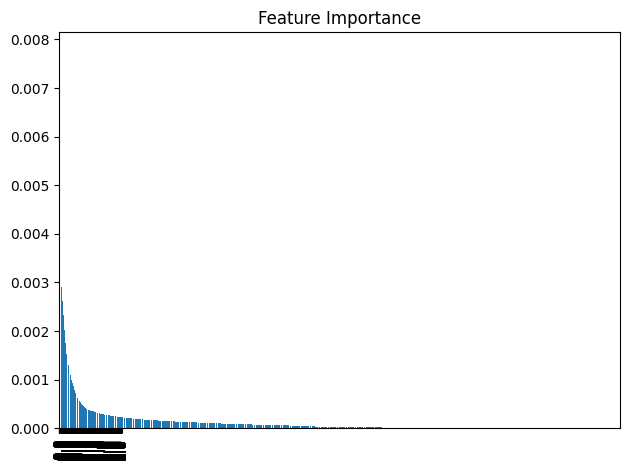

In [18]:
plt.title('Feature Importance')
plt.bar(range(X_train.shape[1]),importances[indices],align='center')
plt.xticks(range(X_train.shape[0]),Y_train, rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.tight_layout()
plt.show()

trop de critaire n ont pas d importance sur le model donc j opte a utiliser une serie de convolution et de max pooling pour reduire la dimentionalite 

In [39]:
X_experiment = []


kernel = np.ones(3)  
pool_size = 2       

for raw in X_train:
    
    raw = raw.flatten()
    
    for _ in range(4):  
        
        raw = np.convolve(raw, kernel, mode='valid')
        
        
        raw = np.array([max(raw[i:i + pool_size]) for i in range(0, len(raw), pool_size)])
    
    
    X_experiment.append(raw)


X_experiment = np.array(X_experiment)


In [41]:
X_test_experiment = []

for raw in X:
    
    raw = raw.flatten()
    
    for _ in range(4):  
        
        raw = np.convolve(raw, kernel, mode='valid')
        
        
        raw = np.array([max(raw[i:i + pool_size]) for i in range(0, len(raw), pool_size)])
    
    
    X_test_experiment.append(raw)
X_test_experiment = np.array(X_test_experiment)

In [45]:
forest2 = RandomForestClassifier(criterion='gini', n_estimators=100, random_state=0, n_jobs=-1)
forest2.fit(X_experiment, Y_train)
importances2 = forest2.feature_importances_
indices2 = np.argsort(importances2)[::-1]
#sfm2 = SelectFromModel(forest2, threshold=0.001, prefit=True) # this deemed useless since for it do something the threshhold must be greater than 0.001 which is too high
#X_selected2 = sfm2.transform(X_experiment)

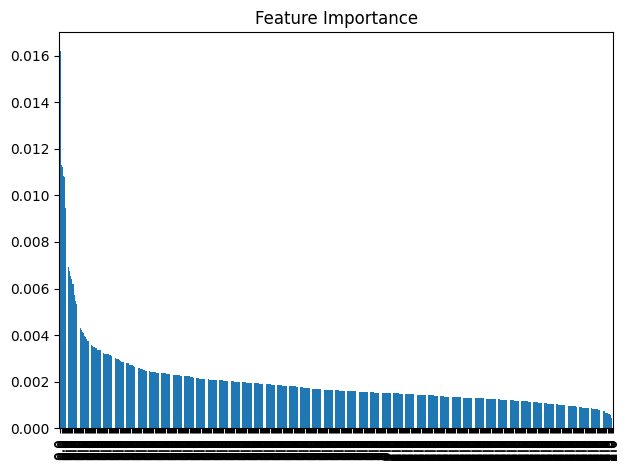

In [47]:
plt.title('Feature Importance')
plt.bar(range(X_experiment.shape[1]),importances2[indices2],align='center')
plt.xticks(range(X_experiment.shape[0]),Y_train, rotation=90)
plt.xlim([-1, X_experiment.shape[1]])
plt.tight_layout()
plt.show()

we already at 50X features and it seems like we can no longer reduce the dimentionality since all the features seems to have a significance

In [49]:
# now let's write the data to csv files
data_train = pd.DataFrame(X_experiment)
data_train['label'] = encoder.inverse_transform(Y_train.reshape(-1, 1)).ravel()
data_train.to_csv('hog/hog_data_train_experiment.csv', index=False)
data_test = pd.DataFrame(X_test_experiment)
data_test['label'] = encoder.inverse_transform(Y.reshape(-1, 1)).ravel()
data_test.to_csv('hog/hog_data_test_experiment.csv', index=False)